In [ ]:
import numpy as np
import pandas as pd
import os
import sys
import glob
import torch.nn as nn
from transformers import AutoConfig
from safetensors.torch import load_file  # comes with HF if safetensors installed
from sklearn.metrics import classification_report, recall_score
import tqdm
import re
import ast
from typing import List
import torch
import matplotlib.pyplot as plt
os.chdir("/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis")
sys.path.append("../../benchmark")
import test_base
from sentence_splitter import split_text_into_sentences
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from BERT_classifier.Classify_report_with_BERT import tf_idf

# Test using a BERT-Classification Model trained on paragraphs to classify an entire report.

**Function:** pdf -> NACE Class

## Load Data

In [ ]:
dataset_path = "data/datasets/german_annual_reports"
dataset_path = "data/datasets/stoxx_600_extended"
dataset_path = "data/datasets/reports_subset_from_full_data_1"
dataset_path = "data/datasets/stoxx_600"
dataset_path = "data/datasets/reports_subset_from_full_data_3"

In [ ]:
over_view_df_path = os.path.join(dataset_path, os.path.basename(dataset_path) + "_overview.csv")

dataset_path_texts = os.path.join(dataset_path, "TXTs")

dataset_name = os.path.basename(dataset_path)

In [ ]:
cos_sim_path = "results/dataset__reports_subset_from_full_data_3_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_1"
cos_sim_report_paths = glob.glob(cos_sim_path + "/*/*.csv")
len(cos_sim_report_paths)

813

In [ ]:
results_path = "results/BERT_classification/dataset__stoxx_600_sentence_len_6__nace_level_1"
results_path = "results/BERT_classification/2_dataset__reports_subset_from_full_data_1_sentence_len_6__nace_level_1"
results_path = "results/BERT_classification/model_0_1__dataset__stoxx_600_sentence_len_6__nace_level_1"
results_path = "results/BERT_classification/test_1_dataset__stoxx_600_sentence_len_6__nace_level_1"
results_path = "results/BERT_classification/model_2_1__with_relevancy__dataset__reports_subset_from_full_data_3_sentence_len_6__nace_level_1"
results_path = "results/BERT_classification/model_1_0__with_relevancy__dataset__reports_subset_from_full_data_3_sentence_len_6__nace_level_1"
reports_results = glob.glob(results_path+ "/*/*.csv")
len(reports_results)

62

In [ ]:
a = [os.path.basename(b).replace("_long.csv", "") for b in cos_sim_report_paths]

In [ ]:
b = [os.path.basename(b).replace("_classifications.csv", "") for b in reports_results]

In [ ]:
# for cos in cos_sim_report_paths: 
#     print(os.path.basename(cos).replace("_long.csv", "") in b)
#     print(os.path.exists(cos))

In [ ]:
nace_classes = pd.read_csv(over_view_df_path, index_col=0, sep=",")
nace_classes.head()

,Symbol,Name,Company is Active,Company Founded Date,Country of Primary Listing Iso3,CUSIP,Date Of First Trade,Entity Country HQ,Entity Credit Parent,NACE,...,ISIN,Primary Equity Listing,Proper Name,Public Company,Region Ticker,Sec is Primary Issue,Sec Type,SEDOL,NACE_Letter,Report
0,CA05335P1099,Auxly Cannabis Group Inc.,1,1987.0,CAN,05335P109,19960301.0,CAN,003V9K-E,1.30,...,CA05335P1099,BDGMQB,Auxly Cannabis Group Inc.,1.0,XLY-CA,1,SHARE,BDGMQB3,A,Auxly Cannabis Group Inc.2.pdf
1,JP3947800003,"MEGMILK SNOW BRAND Co., Ltd.",1,2009.0,JPN,J41966102,20220727.0,JPN,0833Y1-E,1.41,...,JP3947800003,B3ZC07,"MEGMILK SNOW BRAND Co., Ltd.",1.0,MMSBF-US,0,SHARE,BKQN701,A,"MEGMILK SNOW BRAND Co., Ltd.2.pdf"
2,ID1000167901,PT Cilacap Samudera Fishing Industry Tbk,0,1999.0,IDN,Y129H6108,20220527.0,IDN,@NA,3.12,...,ID1000167901,BMBMZG,PT Cilacap Samudera Fishing Industry Tbk,1.0,ASHA-ID,0,SHARE,BMBMZG9,A,PT Cilacap Samudera Fishing Industry Tbk3.pdf
3,JP3843250006,Hokuto Corporation,1,1964.0,JPN,J2224T102,19941202.0,JPN,05HY7N-E,1.30,...,JP3843250006,643271,Hokuto Corporation,1.0,1379-JP,1,SHARE,6432715,A,Hokuto Corporation1.pdf
4,VN000000VTQ6,Viet Trung Quang Binh Joint Stock Co,0,1961.0,VNM,Y937XS108,NaN,VNM,@NA,2.30,...,VN000000VTQ6,BMCR2W,Viet Trung Quang Binh Joint Stock Co,1.0,VTQ-VN,0,SHARE,BMCR2W8,A,Viet Trung Quang Binh Joint Stock Co3.pdf


In [ ]:
report_to_nace_class = nace_classes.dropna(subset=["Report"]).set_index('Report').to_dict()["NACE"]
report_to_nace_class = {report[0][:-4] + ".txt": report[1] for report in report_to_nace_class.items()}
len(report_to_nace_class)

834

In [ ]:
reports_path = glob.glob(os.path.join(dataset_path_texts, "*.txt"))
len(reports_path)

433

## Define Aggregation methods

In [ ]:
def softmax(x):
    e = np.exp(x - np.max(x))   # subtract max for numerical stability
    return e / e.sum()

In [ ]:
def majority_vote(df: pd.DataFrame, scores: list, threshold: float = 0, **kwargs) -> dict:
    
    df.loc[:,"max_class_sim"] = [scores[i] for i in np.argmax(df[scores], 1)]
    df.loc[:,"max_sim"] = df[scores].max(1)
    df = df[df["max_sim"] > threshold]
    evaluation = (df["max_class_sim"].value_counts() / len(df)).sort_values(ascending=False).to_dict()

    return evaluation

In [ ]:
def confidence_weighted_voting(df: pd.DataFrame, scores: list, threshold: float = 0, **kwargs) -> dict:

    df.loc[:,"max_class_sim"] = [scores[i] for i in np.argmax(df[scores], 1)]
    df.loc[:,"max_sim"] = df[scores].max(1)
    df = df[df["max_sim"] > threshold]
    evaluation = (df.groupby("max_class_sim")["max_sim"].sum().sort_values(ascending=False)/len(df)).to_dict()

    return evaluation

In [ ]:
def logit_stacking(df: pd.DataFrame, scores: list, threshold: float = 0, **kwargs) -> dict:

    df.loc[:,"max_sim"] = df[scores].max(1)
    df = df[df["max_sim"] > threshold]

    stacked = df[scores].sum(0)
    
    evaluation = stacked.to_dict()

    return evaluation

In [ ]:
def max_class_voting(df: pd.DataFrame, scores: list, threshold: float = 0, **kwargs) -> dict:

    df.loc[:,"max_class_sim"] = [scores[i] for i in np.argmax(df[scores], 1)]
    df.loc[:,"max_sim"] = df[scores].max(1)
    
    max_sim = df["max_sim"].max()
    res_class = df[df["max_sim"] == max_sim].sum(0)[scores]

    return res_class.to_dict()

In [ ]:
train_df = pd.read_csv("data/training_data/dataset_reports_subset_from_full_data_1__sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_1__2nd_approach__nace_level_1__cos_thres_0.4/full_data.csv")

training_reports = train_df["text"].to_list()

#Build TF-IDF model on all sentences from the training corpus
tfidf_vectorizer = tf_idf.build_tfidf_model(training_reports)

In [ ]:
def tf_idf_weighted(df: pd.DataFrame, scores: list, threshold: float = 0, df_full: pd.DataFrame = None, k = 10) -> dict:
    shortened, ranked = tf_idf.select_top_sentences(
        report_paragraphs=df_full["Sentences"].to_list(),
        vectorizer=tfidf_vectorizer,
        max_words=2000
    )
    df_full = df_full.iloc[np.array(ranked)[:,2][:k]]
    
    #print(len(df_full))

    evaluation = logit_stacking(df_full.copy(), scores, threshold)

    return evaluation  

In [ ]:
def only_use_paragraphs_with_large_cos_sim(df: pd.DataFrame, scores: list, threshold: float = 0, df_full: pd.DataFrame = None, df_cos_sim: pd.DataFrame = None, cos_sim_threshold = 0.4) -> dict:
        
    # apply threshold 
    df_cos_sim_scores = [column for column in df_cos_sim.columns if "Scores" in column]
    df_cos_sim.loc[:,"max_sim"] = df_cos_sim[df_cos_sim_scores].max(1)
    df_cos_sim["use_for_classification"] = df_cos_sim["max_sim"] > cos_sim_threshold

    # join into df_eval (BERT Classification)

    df_merged = pd.merge(df_full, df_cos_sim[["Sentences", "use_for_classification"]], on = "Sentences")
    df_merged = df_merged[df_merged["use_for_classification"]]

    scores = df.columns
    df_merged[scores] = df_merged[scores].apply(softmax, axis=1)
    df_softmax = df_merged[scores]

    evaluation = logit_stacking(df_softmax.copy(), scores, threshold)

    return evaluation  

In [ ]:
def prefilter_binary(df: pd.DataFrame, scores: list, threshold: float = 0, df_full: pd.DataFrame = None, threshold_relevancy: float = 0.5, **kwargs) -> dict:

    # apply threshold
    #print(df_full.columns)

    df_full["is_explanation"] = df_full["Relevancy_sig"] > threshold_relevancy

    df_full = df_full[df_full["is_explanation"]]

    df_full.loc[:,"max_class_sim"] = [scores[i] for i in np.argmax(df_full[scores], 1)]

    #print("\n".join(df_full["Sentences"].to_list()))
    #print(df_full[["Sentences", "max_class_sim"]])
    
    evaluation = logit_stacking(df_full[scores].copy(), scores, threshold)

    return evaluation  

## Define Metrics

In [ ]:
def mean_reciprocal_rank(position_levels):
    """
    Compute Mean Reciprocal Rank (MRR)
    position_levels: list or array of integer ranks (0 = correct, 1 = 2nd, ...)
    """
    ranks = np.array(position_levels) + 1  # convert 0-based to 1-based ranks
    reciprocal_ranks = 1 / ranks
    return np.mean(reciprocal_ranks)

def recall_score(y_true, y_pred):
    y_true_bin = (np.array(y_true) == 0).astype(int)
    y_pred_bin = (np.array(y_pred) == 0).astype(int)
    tp = np.sum((y_true_bin == 1) & (y_pred_bin == 1))
    fn = np.sum((y_true_bin == 1) & (y_pred_bin == 0))
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0


def precision_score(y_true, y_pred):
    y_true_bin = (np.array(y_true) == 0).astype(int)
    y_pred_bin = (np.array(y_pred) == 0).astype(int)
    tp = np.sum((y_true_bin == 1) & (y_pred_bin == 1))
    fp = np.sum((y_true_bin == 0) & (y_pred_bin == 1))
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0


def accuracy_score(y_true, y_pred):
    y_true_bin = (np.array(y_true) == 0).astype(int)
    y_pred_bin = (np.array(y_pred) == 0).astype(int)
    return np.mean(y_true_bin == y_pred_bin)


def f1_score(y_true, y_pred):
    p = precision_score(y_true, y_pred)
    r = recall_score(y_true, y_pred)
    return (2 * p * r) / (p + r) if (p + r) > 0 else 0.0


def mean_reciprocal_rank(position_levels):
    ranks = np.array(position_levels) + 1  # convert 0-based to 1-based ranks
    reciprocal_ranks = 1 / ranks
    return np.mean(reciprocal_ranks)

def top3_acc(position_levels): 
    return np.mean(position_levels < 3)

## Test the aggregation methods

In [ ]:
# for the cos sim approach, load cos_sim csvs

for results_path in reports_results:
    n = os.path.basename(results_path).replace("_classifications.csv", "")
    if os.path.exists(os.path.join(cos_sim_path, n, n + "_long.csv")): 
        df_cos_sim = pd.read_csv(os.path.join(cos_sim_path, n, n + "_long.csv"))
        df_eval = pd.read_csv(results_path, index_col=0)

sentence_in_cos_sim = []
for i in range(len(df_eval)): 
    sentence_in_cos_sim.append(df_eval["Sentences"][i] in df_cos_sim["Sentences"].to_list())
    #print(df_cos_sim["Sentences"].to_list().index(df_eval["Sentences"][i]))
np.all(sentence_in_cos_sim)
df_cos_sim.head()
df_eval.head()

,F,P,L,K,I,A,D,G,E,NO_CLASS,B,J,H,Q,M,N,C,Sentences,Relevancy_sig,Relevancy_over_0_5
0,1.664022,-0.763073,-4.053606,0.155859,0.274904,-3.352322,-3.160292,-1.270979,-1.924898,8.768679,-3.573488,-3.144954,-0.238158,0.873342,-0.153624,0.101030,-0.486479,the commission assessed the proposed modificat...,0.038914,False
1,1.404864,-0.850764,-4.344363,0.257521,0.489722,-3.204204,-3.510474,-1.163106,-1.669083,9.170738,-3.473359,-3.289388,-0.509579,0.310998,-0.196801,0.380019,-0.390851,. performance liaison committee consists of th...,0.041693,False
2,1.284897,-0.908339,-4.386399,0.203362,0.238644,-3.272197,-3.537374,-1.070492,-1.881411,9.270383,-3.600609,-3.051518,-0.408885,0.693381,0.011141,0.162225,-0.203418,the new res was approved by the european commi...,0.039748,False
3,1.060150,-1.084430,-4.145679,0.435527,0.688069,-3.474484,-3.026289,-1.033047,-1.908139,8.730354,-3.266055,-3.021259,0.311188,0.883173,-0.724629,0.136558,-0.618248,a provision for high cost claims arising in re...,0.041636,False
4,-1.571595,-1.976530,1.886727,8.256032,-0.482924,-1.192947,-3.025836,1.648552,-1.608428,0.298638,-2.356384,-1.597690,-0.583452,-3.376449,-2.822176,2.041593,-1.698510,tangible assets assets under development curre...,0.040110,False


In [ ]:
#for agg_func in [majority_vote, confidence_weighted_voting, logit_stacking]: 
#for agg_func in [tf_idf_weighted]: 

results = []

#for agg_func in [only_use_paragraphs_with_large_cos_sim, majority_vote, confidence_weighted_voting, logit_stacking, tf_idf_weighted]: 
for agg_func in [prefilter_binary]: 
    
    print("--------")
    print()
    print(agg_func.__name__)
    print()
    print("--------")
    k = 30
    conf = 0.0
    #for cos_sim_threshold in [0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65]:
    for threshold_relevancy in [0.2,0.3,0.4,0.5,0.6,0.7]:
    #for conf in [0.9]:
    #for k in [5,10,20,30,40,50]:
    #for k in [30]:
        level = 1
        recording = [] 

        #if path_nace_code_descriptions is None: 
        path_nace_code_descriptions = "data/NACE_Rev2_Structure_Explanatory_Notes_EN__1_.tsv"
            
        df_nace_codes_descriptions = pd.read_csv(path_nace_code_descriptions, sep="\t")

        for results_path in tqdm.tqdm((reports_results)): 
        #for results_path in ((reports_results)): 

            # print(results_path)

            report_name = os.path.basename(results_path.split("/")[-2])
            label = report_to_nace_class.get(report_name)

            level_1_label = test_base.get_all_level(label)[1]

            df_eval = pd.read_csv(results_path, index_col=0)
            
            # ONLY USE TOP K
            df_eval = df_eval
            
            scores = df_eval.columns.drop(["Sentences", "Relevancy_sig", "Relevancy_over_0_5"])

            df_eval[scores] = df_eval[scores].apply(softmax, axis=1)
            df_softmax = df_eval[scores]
            if agg_func == only_use_paragraphs_with_large_cos_sim: 

                base_name = os.path.basename(results_path).replace("_classifications.csv", "")

                # load cos sim df if it exists
                if os.path.exists(os.path.join(cos_sim_path, base_name, base_name + "_long.csv")): 
                    df_cos_sim = pd.read_csv(os.path.join(cos_sim_path, base_name, base_name + "_long.csv"))
                    df_eval = pd.read_csv(results_path, index_col=0)
                else:
                    continue

                # check that the sentences are the same
                sentence_in_cos_sim = []
                for i in range(len(df_eval)): 
                    sentence_in_cos_sim.append(df_eval["Sentences"][i] in df_cos_sim["Sentences"].to_list())
                if not np.all(sentence_in_cos_sim): 
                    print("Not the same reports in cos sim and df_eval: ", report_name)
                    continue

                class_eval_dict = agg_func(
                    df_softmax, scores, threshold=conf, df_full=df_eval, df_cos_sim=df_cos_sim 
                )

            else: 
                class_eval_dict = agg_func(
                    df_softmax, scores, threshold=conf, df_full=df_eval.copy(), k = k, threshold_relevancy =threshold_relevancy
                )
                
            # # get label of the report
            label = report_to_nace_class.get(os.path.basename(results_path).replace("_classifications.csv", ""))


            try: 
                if isinstance(label, float) or isinstance(label, int):                     
                    if len(str(label).split(".")[0]) == 1: 
                        label = "0" + str(label) 

                label_description = df_nace_codes_descriptions[df_nace_codes_descriptions["CODE"] == str(label)]["NAME"].iloc[0]
                evaluation = test_base.get_evaluation(class_eval_dict, label, df_nace_codes_descriptions, level)
            except IndexError: 
                print(label, "index_error")
                label_description = ""
                evaluation = {}
            recording.append({"name": os.path.basename(results_path), "NACE": label, "label_description": label_description, **evaluation})
            print(evaluation)
            df_recording = pd.DataFrame(recording)
            #df_recording.to_csv(os.path.join(result_path, "recordings.csv"))

        print()
        print("Treshold: ", conf)
        #print("Top k (TF-IDF): ", k)
        #print("cos_sim_threshold: ", cos_sim_threshold)
        print("MRR: ", mean_reciprocal_rank(df_recording["position_lvl_1"].dropna()))
        print("Top3 Acc.: ", top3_acc(df_recording["position_lvl_1"].dropna()))
        df_recording = df_recording.dropna(subset=["nace_lvl_1", "first_class_1"])
        y_true = df_recording["nace_lvl_1"] 
        y_pred = df_recording["first_class_1"]
        print(classification_report(y_true, y_pred))

        txt_results = "MRR: " + str(mean_reciprocal_rank(df_recording["position_lvl_1"].dropna())) + "\nTop3 Acc.: " + str(top3_acc(df_recording["position_lvl_1"].dropna()))+"\n"+classification_report(y_true, y_pred)

        results.append(txt_results)

--------

prefilter_binary

--------


  0%|                                                                                                                                                                                          | 0/62 [00:00<?, ?it/s]

/tmp/ipykernel_3992233/2949831678.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_full.loc[:,"max_class_sim"] = [scores[i] for i in np.argmax(df_full[scores], 1)]
  2%|██▊                                                                                                                                                                               | 1/62 [00:00<00:27,  2.18it/s]/tmp/ipykernel_3992233/2949831678.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_full.loc[:,"max_class_sim"] = [scores

{'nace_lvl_1': 'L', 'position_lvl_1': 15, 'classes_lvl_1': 16, 'classification_lvl_1': {'G_WHOLESALE AND RETAIL TRADE; REPAIR OF MOTOR VEHICLES AND MOTORCYCLES': 6.0774617506513895, 'C_MANUFACTURING': 2.990379019205165, 'M_PROFESSIONAL, SCIENTIFIC AND TECHNICAL ACTIVITIES': 2.0076809795701367, 'K_FINANCIAL AND INSURANCE ACTIVITIES': 0.9643450656109918, 'Q_HUMAN HEALTH AND SOCIAL WORK ACTIVITIES': 0.06544024606612486, 'N_ADMINISTRATIVE AND SUPPORT SERVICE ACTIVITIES': 0.04692997360611757, 'F_CONSTRUCTION': 0.03585536288499568, 'H_TRANSPORTATION AND STORAGE': 0.01716991895001384, 'P_EDUCATION': 0.012395677121712667, 'E_WATER SUPPLY; SEWERAGE, WASTE MANAGEMENT AND REMEDIATION ACTIVITIES': 0.011198771187689843, 'I_ACCOMMODATION AND FOOD SERVICE ACTIVITIES': 0.010889928961097878, 'J_INFORMATION AND COMMUNICATION': 0.0046769983025795, 'D_ELECTRICITY, GAS, STEAM AND AIR CONDITIONING SUPPLY': 0.004020718098573605, 'B_MINING AND QUARRYING': 0.003723467677995858, 'A_AGRICULTURE, FORESTRY AND FIS

/tmp/ipykernel_3992233/2949831678.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_full.loc[:,"max_class_sim"] = [scores[i] for i in np.argmax(df_full[scores], 1)]
  5%|████████▌                                                                                                                                                                         | 3/62 [00:00<00:11,  5.31it/s]/tmp/ipykernel_3992233/2949831678.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_full.loc[:,"max_class_sim"] = [scores

...

/tmp/ipykernel_3992233/2949831678.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_full.loc[:,"max_class_sim"] = [scores[i] for i in np.argmax(df_full[scores], 1)]
/tmp/ipykernel_3992233/2949831678.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_full.loc[:,"max_class_sim"] = [scores[i] for i in np.argmax(df_full[scores], 1)]
 98%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

{'nace_lvl_1': 'E', 'position_lvl_1': 12, 'classes_lvl_1': 16, 'classification_lvl_1': {'F_CONSTRUCTION': 2.0112414349359082, 'M_PROFESSIONAL, SCIENTIFIC AND TECHNICAL ACTIVITIES': 1.990016858457787, 'G_WHOLESALE AND RETAIL TRADE; REPAIR OF MOTOR VEHICLES AND MOTORCYCLES': 1.8050757639276924, 'N_ADMINISTRATIVE AND SUPPORT SERVICE ACTIVITIES': 0.11005726323820687, 'C_MANUFACTURING': 0.06444411738400928, 'K_FINANCIAL AND INSURANCE ACTIVITIES': 0.05027024944862107, 'H_TRANSPORTATION AND STORAGE': 0.03038026144758542, 'P_EDUCATION': 0.0072540355893647625, 'L_REAL ESTATE ACTIVITIES': 0.006012615539510935, 'I_ACCOMMODATION AND FOOD SERVICE ACTIVITIES': 0.005144444611154759, 'B_MINING AND QUARRYING': 0.004285087116658377, 'Q_HUMAN HEALTH AND SOCIAL WORK ACTIVITIES': 0.004156574696641668, 'E_WATER SUPPLY; SEWERAGE, WASTE MANAGEMENT AND REMEDIATION ACTIVITIES': 0.0030621456688199734, 'J_INFORMATION AND COMMUNICATION': 0.0024742133684408636, 'D_ELECTRICITY, GAS, STEAM AND AIR CONDITIONING SUPPLY

/tmp/ipykernel_3992233/2949831678.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_full.loc[:,"max_class_sim"] = [scores[i] for i in np.argmax(df_full[scores], 1)]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 62/62 [00:16<00:00,  3.86it/s]

{'nace_lvl_1': 'Q', 'position_lvl_1': 1, 'classes_lvl_1': 16, 'classification_lvl_1': {'M_PROFESSIONAL, SCIENTIFIC AND TECHNICAL ACTIVITIES': 1.9815780031131975, 'Q_HUMAN HEALTH AND SOCIAL WORK ACTIVITIES': 0.9595531356067127, 'K_FINANCIAL AND INSURANCE ACTIVITIES': 0.12921004926414317, 'N_ADMINISTRATIVE AND SUPPORT SERVICE ACTIVITIES': 0.014719787792666413, 'H_TRANSPORTATION AND STORAGE': 0.011923831292052774, 'G_WHOLESALE AND RETAIL TRADE; REPAIR OF MOTOR VEHICLES AND MOTORCYCLES': 0.007989831088301058, 'C_MANUFACTURING': 0.0050172084223424375, 'F_CONSTRUCTION': 0.004509598552580509, 'P_EDUCATION': 0.0044597435808096065, 'J_INFORMATION AND COMMUNICATION': 0.003849650630644003, 'I_ACCOMMODATION AND FOOD SERVICE ACTIVITIES': 0.003261439800340813, 'E_WATER SUPPLY; SEWERAGE, WASTE MANAGEMENT AND REMEDIATION ACTIVITIES': 0.0010450816768527592, 'D_ELECTRICITY, GAS, STEAM AND AIR CONDITIONING SUPPLY': 0.0009007858943377514, 'B_MINING AND QUARRYING': 0.0005659844263136515, 'A_AGRICULTURE, FO


/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis/nace_git/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis/nace_git/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis/nace_git/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: Undefi

In [ ]:
for result in results:
    print(result)   

MRR: 0.5499483939000068
Top3 Acc.: 0.5645161290322581
              precision    recall  f1-score   support

           A       1.00      1.00      1.00         2
           B       0.67      0.67      0.67         6
           C       1.00      0.33      0.50         3
           D       0.43      0.60      0.50         5
           E       0.00      0.00      0.00         1
           F       0.43      0.75      0.55         4
           G       0.33      0.29      0.31         7
           H       0.80      1.00      0.89         4
           I       1.00      0.50      0.67         4
           J       0.00      0.00      0.00         3
           K       0.50      0.50      0.50         4
           L       0.50      0.50      0.50         6
           M       0.14      0.17      0.15         6
           N       0.00      0.00      0.00         4
           Q       0.00      0.00      0.00         3

    accuracy                           0.44        62
   macro avg       0.45   

In [ ]:
results_path

'results/BERT_classification/model_1_0__with_relevancy__dataset__reports_subset_from_full_data_3_sentence_len_6__nace_level_1/GPP Resources Bhd.2.txt/GPP Resources Bhd.2.txt_classifications.csv'

In [ ]:
df_recording

,name,NACE,label_description,nace_lvl_1,position_lvl_1,classes_lvl_1,classification_lvl_1,first_class_1
0,Shanghai Industrial Holdings Limited3.txt_clas...,68.1,Buying and selling of own real estate,L,15,16,{'G_WHOLESALE AND RETAIL TRADE; REPAIR OF MOTO...,G
1,Kitac Corporation2.txt_classifications.csv,74.9,"Other professional, scientific and technical a...",M,11,16,"{'F_CONSTRUCTION': 1.891006692721428, 'L_REAL ...",F
2,China Energy Engineering Corp. Ltd.1.txt_class...,42.22,Construction of utility projects for electrici...,F,4,16,"{'D_ELECTRICITY, GAS, STEAM AND AIR CONDITIONI...",D
3,Acadian Timber Corp.1.txt_classifications.csv,02.3,Gathering of wild growing non-wood products,A,0,16,"{'A_AGRICULTURE, FORESTRY AND FISHING': 5.9074...",A
4,"Shake Shack, Inc.1.txt_classifications.csv",56.1,Restaurants and mobile food service activities,I,0,16,{'I_ACCOMMODATION AND FOOD SERVICE ACTIVITIES'...,I
5,Cora Gold Ltd.1.txt_classifications.csv,07.29,Mining of other non-ferrous metal ores,B,0,16,"{'B_MINING AND QUARRYING': 3.94170140818196, '...",B
6,NetCapital Inc1.txt_classifications.csv,70.22,Business and other management consultancy acti...,M,2,16,{'K_FINANCIAL AND INSURANCE ACTIVITIES': 2.196...,K
7,Viking Supply Ships AB3.txt_classifications.csv,50.2,Sea and coastal freight water transport,H,0,16,{'H_TRANSPORTATION AND STORAGE': 2.98902224694...,H
8,Oji Holdings Corp.2.txt_classifications.csv,17.21,Manufacture of corrugated paper and paperboard...,C,0,16,"{'C_MANUFACTURING': 39.25570779788276, 'A_AGRI...",C
9,Tecnicas Reunidas SA1.txt_classifications.csv,71.12,Engineering activities and related technical c...,M,3,16,"{'D_ELECTRICITY, GAS, STEAM AND AIR CONDITIONI...",D


In [ ]:
df_recording

,name,NACE,label_description,nace_lvl_1,position_lvl_1,classes_lvl_1,classification_lvl_1,first_class_1
0,Shanghai Industrial Holdings Limited3.txt_clas...,68.1,Buying and selling of own real estate,L,15,16,{'G_WHOLESALE AND RETAIL TRADE; REPAIR OF MOTO...,G
1,Kitac Corporation2.txt_classifications.csv,74.9,"Other professional, scientific and technical a...",M,11,16,"{'F_CONSTRUCTION': 1.891006692721428, 'L_REAL ...",F
2,China Energy Engineering Corp. Ltd.1.txt_class...,42.22,Construction of utility projects for electrici...,F,4,16,"{'D_ELECTRICITY, GAS, STEAM AND AIR CONDITIONI...",D
3,Acadian Timber Corp.1.txt_classifications.csv,02.3,Gathering of wild growing non-wood products,A,0,16,"{'A_AGRICULTURE, FORESTRY AND FISHING': 5.9074...",A
4,"Shake Shack, Inc.1.txt_classifications.csv",56.1,Restaurants and mobile food service activities,I,0,16,{'I_ACCOMMODATION AND FOOD SERVICE ACTIVITIES'...,I
5,Cora Gold Ltd.1.txt_classifications.csv,07.29,Mining of other non-ferrous metal ores,B,0,16,"{'B_MINING AND QUARRYING': 3.94170140818196, '...",B
6,NetCapital Inc1.txt_classifications.csv,70.22,Business and other management consultancy acti...,M,2,16,{'K_FINANCIAL AND INSURANCE ACTIVITIES': 2.196...,K
7,Viking Supply Ships AB3.txt_classifications.csv,50.2,Sea and coastal freight water transport,H,0,16,{'H_TRANSPORTATION AND STORAGE': 2.98902224694...,H
8,Oji Holdings Corp.2.txt_classifications.csv,17.21,Manufacture of corrugated paper and paperboard...,C,0,16,"{'C_MANUFACTURING': 39.25570779788276, 'A_AGRI...",C
9,Tecnicas Reunidas SA1.txt_classifications.csv,71.12,Engineering activities and related technical c...,M,3,16,"{'D_ELECTRICITY, GAS, STEAM AND AIR CONDITIONI...",D


In [ ]:
df_eval = pd.read_csv(reports_results[4], index_col=0)
df_eval

,F,P,L,K,I,A,D,G,E,NO_CLASS,B,J,H,Q,M,N,C,Sentences,Relevancy_sig,Relevancy_over_0_5
0,1.790926,-2.950426,8.784149,1.153100,-0.896264,-0.843729,-1.486517,-0.050514,-0.793825,-3.574809,-0.112638,-2.060619,-1.794408,-2.657238,-2.021282,-0.325739,-1.971066,for operating leases fixed lease payments are ...,0.042210,False
1,1.305863,-0.868231,-4.381179,0.074308,0.133430,-3.352684,-3.435235,-1.113234,-1.978193,9.184181,-3.590613,-3.035022,-0.301009,0.891438,0.115568,0.112503,-0.235785,in march a claim was filed against shake shack...,0.053038,False
2,0.862728,-1.246716,-4.248559,1.262194,0.690265,-3.122127,-3.452925,-0.741565,-1.500856,9.023352,-3.120336,-3.382283,-0.187090,-0.131146,-1.054996,0.513170,-0.439719,in thousands except per share amounts numerato...,0.040584,False
3,0.983799,-2.306071,-2.954977,1.277493,3.016885,-3.945234,-2.280469,0.166276,-1.130749,5.023525,-1.723238,-4.175759,1.303777,-1.208584,-2.719291,0.848109,-1.085804,reduction in occupancy and related expenses du...,0.039465,False
4,1.113867,-1.029451,-4.299654,0.449931,0.278704,-3.292719,-3.354713,-1.002082,-1.854073,9.182098,-3.396574,-3.134612,-0.115487,0.654580,-0.343419,0.197108,-0.358366,we are the sole managing member of sse holding...,0.089097,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1137,1.316307,-1.066876,-4.399717,0.322732,0.466283,-3.237982,-3.516679,-0.983055,-1.692848,9.252523,-3.511193,-3.251415,-0.389837,0.386547,-0.280829,0.261700,-0.171878,additionally we estimate the amount of tra pay...,0.067352,False
1138,0.955959,-1.172765,-4.412750,0.580277,0.249147,-3.378450,-3.391344,-0.686584,-1.919170,9.161249,-3.348346,-3.199270,0.124441,0.548157,-0.505170,0.282483,-0.356145,december december shack sales receivables lice...,0.044391,False
1139,1.411286,-0.983796,-4.373528,0.173030,0.288846,-3.210726,-3.442297,-1.076256,-1.654460,9.217852,-3.530365,-3.247608,-0.500486,0.411253,-0.070053,0.232005,-0.140258,if we are not effective in addressing environm...,0.102469,False
1140,1.052185,-1.281172,-4.332217,1.009470,0.752874,-3.109811,-3.588821,-0.735198,-1.420186,9.099059,-3.232014,-3.465859,-0.356134,-0.266015,-0.905022,0.557911,-0.312367,impairment and loss on disposal of assets for ...,0.039682,False


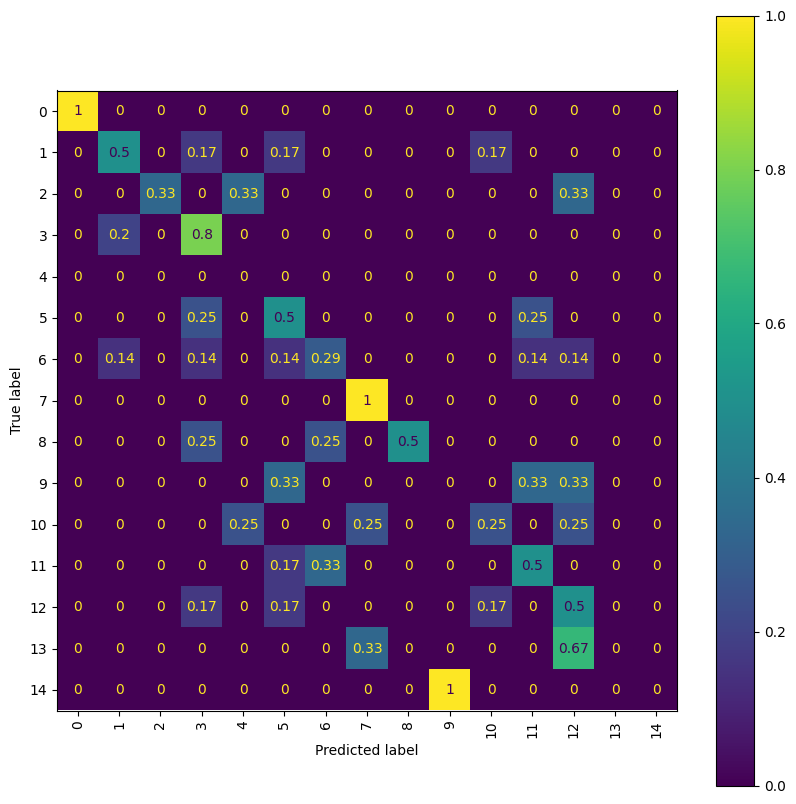

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_true, y_pred, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm)#, display_labels=list(label_mapping.keys()))
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation="vertical")
plt.show()


In [ ]:
df_recording

,name,NACE,label_description,nace_lvl_1,position_lvl_1,classes_lvl_1,classification_lvl_1,first_class_1
0,Shanghai Industrial Holdings Limited3.txt_clas...,68.1,Buying and selling of own real estate,L,15,16,{'G_WHOLESALE AND RETAIL TRADE; REPAIR OF MOTO...,G
1,Kitac Corporation2.txt_classifications.csv,74.9,"Other professional, scientific and technical a...",M,11,16,"{'F_CONSTRUCTION': 1.891006692721428, 'L_REAL ...",F
2,China Energy Engineering Corp. Ltd.1.txt_class...,42.22,Construction of utility projects for electrici...,F,4,16,"{'D_ELECTRICITY, GAS, STEAM AND AIR CONDITIONI...",D
3,Acadian Timber Corp.1.txt_classifications.csv,02.3,Gathering of wild growing non-wood products,A,0,16,"{'A_AGRICULTURE, FORESTRY AND FISHING': 5.9074...",A
4,"Shake Shack, Inc.1.txt_classifications.csv",56.1,Restaurants and mobile food service activities,I,0,16,{'I_ACCOMMODATION AND FOOD SERVICE ACTIVITIES'...,I
5,Cora Gold Ltd.1.txt_classifications.csv,07.29,Mining of other non-ferrous metal ores,B,0,16,"{'B_MINING AND QUARRYING': 3.94170140818196, '...",B
6,NetCapital Inc1.txt_classifications.csv,70.22,Business and other management consultancy acti...,M,2,16,{'K_FINANCIAL AND INSURANCE ACTIVITIES': 2.196...,K
7,Viking Supply Ships AB3.txt_classifications.csv,50.2,Sea and coastal freight water transport,H,0,16,{'H_TRANSPORTATION AND STORAGE': 2.98902224694...,H
8,Oji Holdings Corp.2.txt_classifications.csv,17.21,Manufacture of corrugated paper and paperboard...,C,0,16,"{'C_MANUFACTURING': 39.25570779788276, 'A_AGRI...",C
9,Tecnicas Reunidas SA1.txt_classifications.csv,71.12,Engineering activities and related technical c...,M,3,16,"{'D_ELECTRICITY, GAS, STEAM AND AIR CONDITIONI...",D


In [ ]:
df_eval.max()

F                                                              8.392453
P                                                              1.495569
L                                                              8.842917
K                                                              8.393605
I                                                              9.037591
A                                                             -0.669066
D                                                              7.414564
G                                                              8.810517
E                                                              1.884953
NO_CLASS                                                       9.385414
B                                                               9.03061
J                                                              0.860141
H                                                              8.692461
Q                                                              7

In [ ]:
df_softmax = df_eval[scores].apply(softmax, axis=1)
df_softmax.mean(0)

F           0.022863
P           0.000120
L           0.049331
K           0.122866
I           0.058842
A           0.000048
D           0.002859
G           0.022247
E           0.000499
NO_CLASS    0.695476
B           0.002029
J           0.000033
H           0.007866
Q           0.003523
M           0.005773
N           0.002895
C           0.002731
dtype: float64

In [ ]:
df_softmax["max_class_sim"] = [scores[i] for i in np.argmax(df_softmax[scores], 1)]
df_softmax["max_sim"] = df_softmax[scores].max(1)
(df_softmax.groupby("max_class_sim")["max_sim"].sum().sort_values(ascending=False)/len(df_softmax)).to_dict()

{'NO_CLASS': 0.6860833430668805,
 'K': 0.11792112278369823,
 'I': 0.05594877900944467,
 'L': 0.047566160628856324,
 'F': 0.02084250315693208,
 'G': 0.019922589656187355,
 'H': 0.006336133938671145,
 'M': 0.0053603786250235475,
 'Q': 0.003119008896836354,
 'D': 0.002552607447466296,
 'B': 0.0017488981244857247,
 'C': 0.0013235169783803289,
 'N': 0.0008034513949105235}